# Notebook 3d — Balanced RF (imblearn) con CV por animal: Patrón de lesiones (2 clases) **con explotación**
### Tuberculosis bovina

Target: **Patron_lesiones_3**, restringido a **0=localizado, 1=generalizado**
(se excluyen los animales sin lesión, `Patron_lesiones_3 == -1`).
Evaluación con CV por animal (RepeatedStratifiedKFold) incluyendo **Expl como covariable
categórica fija** junto a los biomarcadores.

> **Nota metodológica:** variante de `03d_CV_Animal_ConExplotacion_PatronLesiones2` que sustituye
> `RandomForestClassifier` (con `class_weight="balanced"`) por `BalancedRandomForestClassifier`
> de `imblearn`, que remuestrea cada árbol sobre un bootstrap balanceado entre clases en vez de
> reponderar la función de pérdida, para combatir el desbalanceo de clases.

> **Pregunta de investigación:** ¿añade la explotación capacidad predictiva adicional
> a los biomarcadores para discriminar el patrón lesional (localizado vs. generalizado)
> en los animales lesionados?

**Comparar con:**
- *Notebook 3d (3 clases)*: mismo análisis incluyendo también los animales sin lesión (-1).
- *Notebook 3d2 (RandomForestClassifier + class_weight="balanced")*: mismo pipeline con el RF
  estándar de scikit-learn.
- *Este notebook*: señal de biomarcadores **condicionada a la granja conocida**, solo en
  animales lesionados, usando Balanced Random Forest (imblearn).

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold)
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score, confusion_matrix)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

import os

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "Patron_lesiones_3")
d = tb.drop_sparse_rows(d)

n_before = len(d)
d = d[d["Patron_lesiones_3"] != -1].reset_index(drop=True)
print(f"Filtrado a 2 clases (0/1): {n_before - len(d)} fila(s) eliminada(s) (Patron_lesiones_3 == -1). "
      f"n restante = {len(d)}.")

EXPL_COL = tb.GROUP_COL
FEATURES_BIO = tb.MODEL_FEATURES
FEATURES_ALL = tb.MODEL_FEATURES + [EXPL_COL]



NUM_3D = tb.NUM_FEATURES
#remove


CAT_3D = tb.CAT_FEATURES + [EXPL_COL]
print(CAT_3D)

#vamos a trabajar sólo con las siguientes feaures

#FEATURES_ALL = ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q_log", "EDAD", "ANAPLASMA","SEXO", "RAZA2"] +[EXPL_COL]
FEATURES_ALL = ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q_log", "EDAD", "ANAPLASMA", "RAZA2"] +[EXPL_COL]
X_all = d[FEATURES_ALL].copy()
y     = d["Patron_lesiones_3"].astype(int).values

print(f"Dataset: n={len(y)}")
print(f"Features biomarcadores ({len(FEATURES_ALL)}): {FEATURES_ALL}")
print(f"Covariable adicional: {EXPL_COL} — niveles: {sorted(d[EXPL_COL].unique())}")
print("Distribución de clases:")
print(pd.Series(y).value_counts().sort_index())
print("Balanced acc. azar (2 clases) = 0.5")

drop_sparse_rows: 3 fila(s) eliminada(s) (>4 NaN en features). n restante = 103.
Filtrado a 2 clases (0/1): 40 fila(s) eliminada(s) (Patron_lesiones_3 == -1). n restante = 63.
['RAZA2', 'Expl']
Dataset: n=63
Features biomarcadores (7): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'ANAPLASMA', 'RAZA2', 'Expl']
Covariable adicional: Expl — niveles: ['VA32D', 'VC30D', 'VC94C', 'WZ72B']
Distribución de clases:
0    40
1    23
Name: count, dtype: int64
Balanced acc. azar (2 clases) = 0.5


In [2]:
#X_all["SEXO"].describe()

### Feature SEXO

No vamos a utilizar sexo porque de 63 datos, el sexo es F para 59

## 2. Balanced Random Forest (imblearn) y estrategia de validación cruzada

**CV por animal con Expl como feature fija (RepeatedStratifiedKFold, 5×10):**
- Estratificado por `y` (2 clases: localizado vs. generalizado).
- `Expl` entra como feature categórica (OHE); la selección hacia atrás opera solo sobre biomarcadores.
- El desbalanceo de clases se corrige con `BalancedRandomForestClassifier` (imblearn): cada árbol
  se entrena sobre un bootstrap remuestreado para igualar el nº de casos por clase
  (`sampling_strategy="all"`, `replacement=True`), en vez de `class_weight="balanced"` sobre el RF
  estándar.

In [25]:
def make_rf(n_estimators=100, min_samples_leaf=5):
    return BalancedRandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        sampling_strategy="not minority", #all  # remuestrea todas las clases al tamaño de la minoritaria
        replacement=True,
        bootstrap=True,
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_3d(feature_list, n_estimators=100):
    """Pipeline con Expl como covariable categórica fija."""
    num_f = [f for f in feature_list if f in NUM_3D]
    cat_f = [f for f in feature_list if f in CAT_3D]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf(n_estimators=n_estimators))])

CV_OUTER = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)

def cv_metrics_3d(bio_features, X, y, cv=None, detailed=False, n_estimators=100):
    """Balanced accuracy, ROC-AUC, sensibilidad y especificidad (clase positiva = 1, generalizado). Expl siempre incluida."""
    if cv is None:
        cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    feats = list(bio_features) + ([EXPL_COL] if EXPL_COL not in bio_features else [])
    Xs = X[feats]
    pipe_tmpl = make_pipe_3d(feats, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        if len(np.unique(y[te])) < 2: continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        p    = pf.predict_proba(Xs.iloc[te])
        pred = pf.predict(Xs.iloc[te])
        bal  = balanced_accuracy_score(y[te], pred)
        try:
            roc = roc_auc_score(y[te], p[:, 1])
        except Exception:
            roc = np.nan
        tn, fp, fn, tp = confusion_matrix(y[te], pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan  # recall clase 1 = generalizado
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan  # recall clase 0 = localizado
        rows.append(dict(bal_acc=bal, roc_mac=roc, sens=sens, spec=spec,
                         tn=tn, fp=fp, fn=fn, tp=tp))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.bal_acc.mean(), df_r.bal_acc.std()

print("Evaluación baseline Balanced RF (imblearn, todos los biomarcadores + Expl, CV por animal):")
base_m, base_s = cv_metrics_3d(FEATURES_ALL, X_all, y)
print(f"  BAL_ACC = {base_m:.3f} ± {base_s:.3f}")
print(f"  Balanced acc. azar (2 clases) = 0.5")

Evaluación baseline Balanced RF (imblearn, todos los biomarcadores + Expl, CV por animal):
  BAL_ACC = 0.702 ± 0.103
  Balanced acc. azar (2 clases) = 0.5


## 3. Pipeline de selección de características

Eliminación hacia atrás sobre **biomarcadores** con `Expl` siempre presente:
1. Importancia de permutación sobre modelo completo → ranking de biomarcadores.
2. Eliminación hacia atrás; `Expl` fija en cada paso.
3. Subconjunto más pequeño con BAL_ACC ≥ máx − 1·DE.

Paso 1: Ajustando RF completo (biomarcadores + Expl)...
OOB Score (en muestra): 0.714

Ranking importancia de permutación (biomarcadores + Expl):
                 pretty  imp_mean  imp_std
                   Expl    0.1299   0.0441
                 Calcio    0.0149   0.0141
     Anaplasma spp. (+)    0.0070   0.0137
             Vitamina D   -0.0003   0.0086
log(1+Carga piroplasma)   -0.0130   0.0362
                   Raza   -0.0162   0.0154
            Edad (años)   -0.0221   0.0222


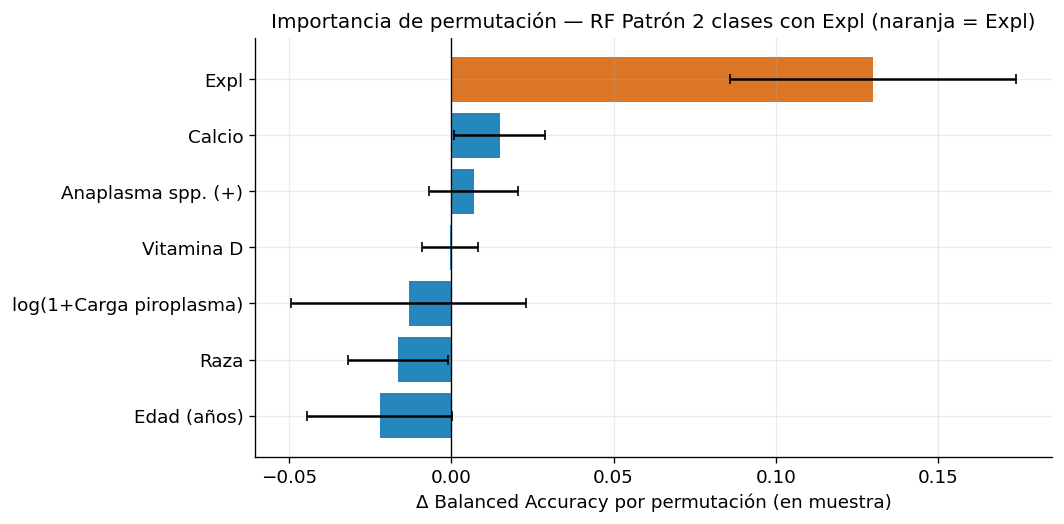

In [26]:
print("Paso 1: Ajustando RF completo (biomarcadores + Expl)...")
full_pipe = make_pipe_3d(FEATURES_ALL).fit(X_all, y)
print(f"OOB Score (en muestra): {full_pipe.named_steps['clf'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="accuracy",
    #scoring="f1",
    n_repeats=2000,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  FEATURES_ALL,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print("\nRanking importancia de permutación (biomarcadores + Expl):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
order = imp_df.sort_values("imp_mean")
colors_bar = [PALETTE[1] if f == EXPL_COL else PALETTE[0] for f in order.feature]
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=colors_bar, capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ Balanced Accuracy por permutación (en muestra)")
ax.set_title("Importancia de permutación — RF Patrón 2 clases con Expl (naranja = Expl)")
plt.tight_layout(); plt.savefig("figures/fig_03d2bal_perm_importance_full.png"); plt.show()

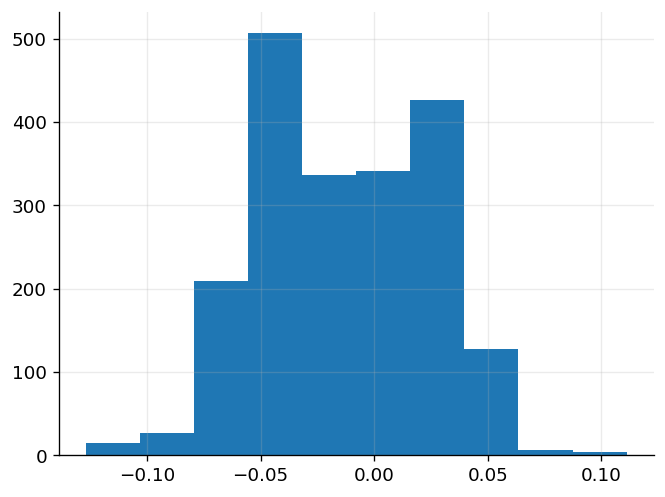

[-0.07936508  0.04761905]


In [27]:
plt.figure()
plt.hist(pi["importances"][2,:])
plt.show()

q = np.quantile(pi["importances"][2,:], [0.025, 0.975])

print(q)

(1000, 2)
[0.06145556 0.1997381 ]
Expl: [0.04761905 0.20634921]


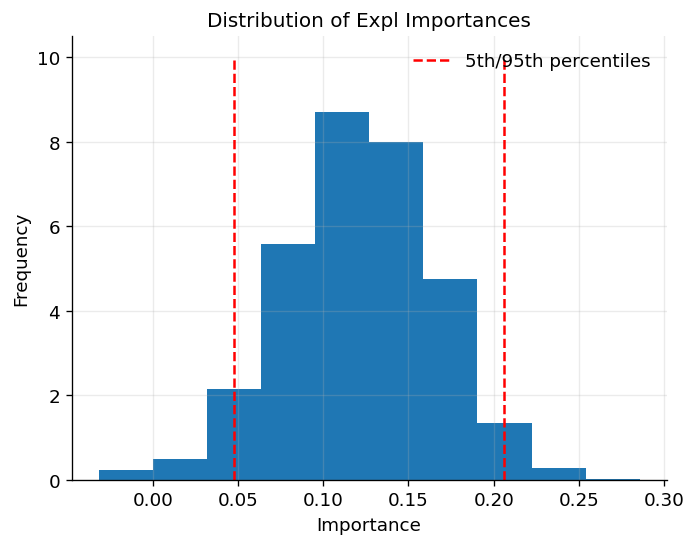

(1000, 2)
[-0.00017698  0.03174603]
CALCIO: [0.         0.03174603]


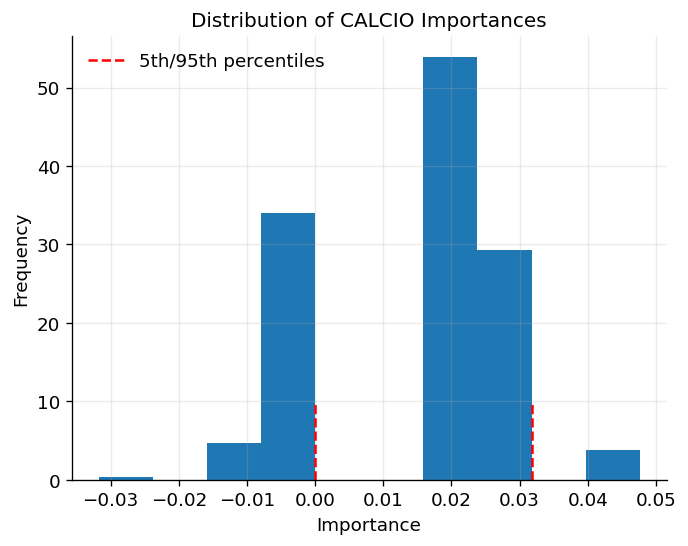

(1000, 2)
[-0.01587302  0.03174603]
ANAPLASMA: [-0.01587302  0.03174603]


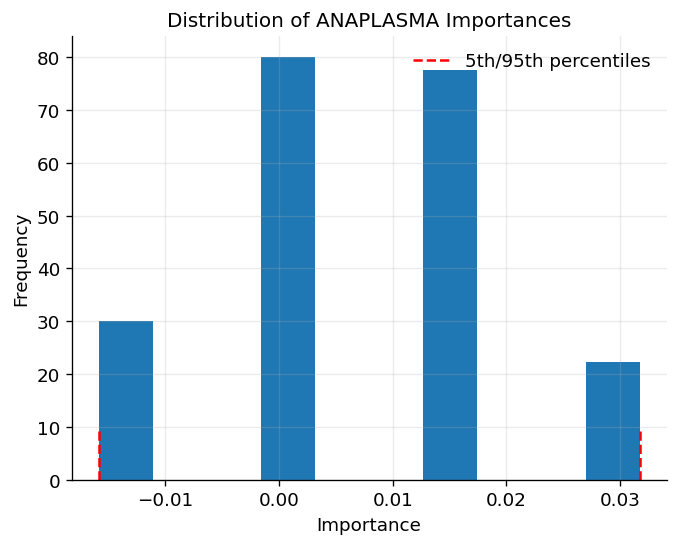

(1000, 2)
[-0.01587302  0.01587302]
VITAMINA_D: [-0.01587302  0.01587302]


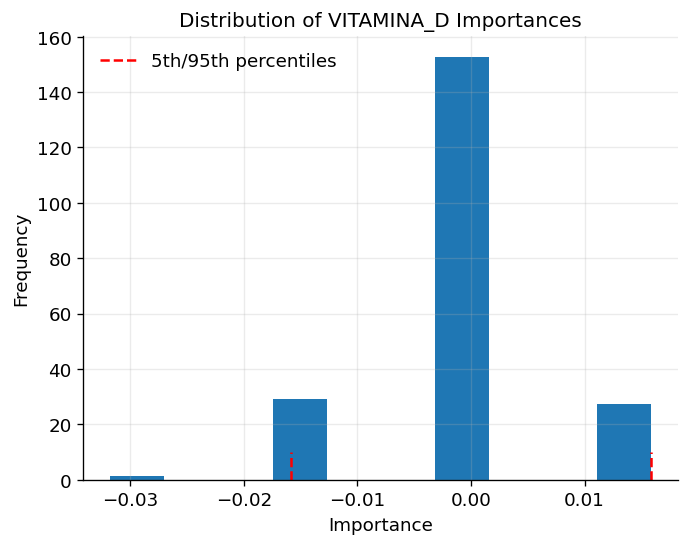

(1000, 2)
[-0.0730254   0.04761905]
PIROPLASMA_Q_log: [-0.07936508  0.04761905]


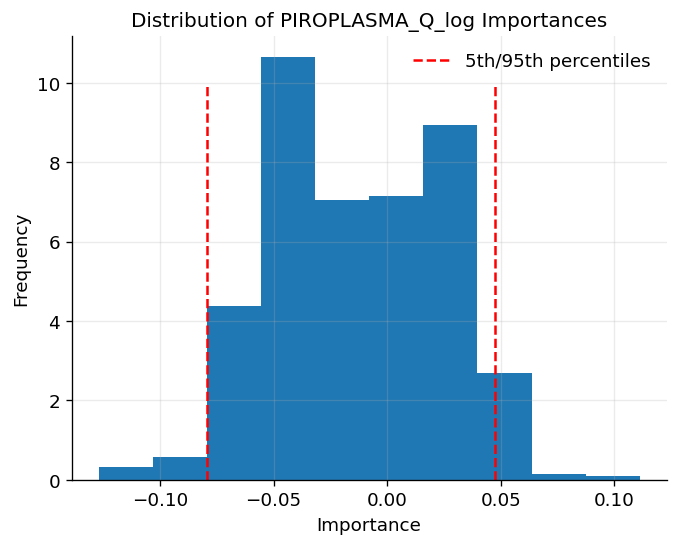

(1000, 2)
[-0.04495079  0.00808968]
RAZA2: [-0.04761905  0.01587302]


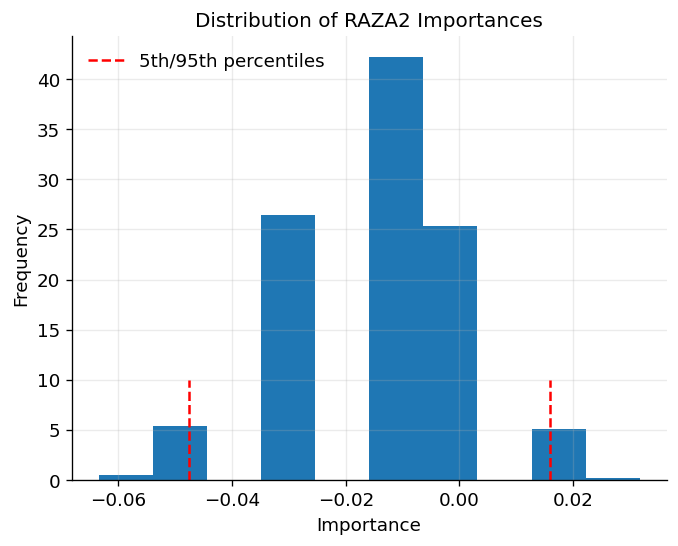

(1000, 2)
[-0.06257778  0.01587302]
EDAD: [-0.06349206  0.01587302]


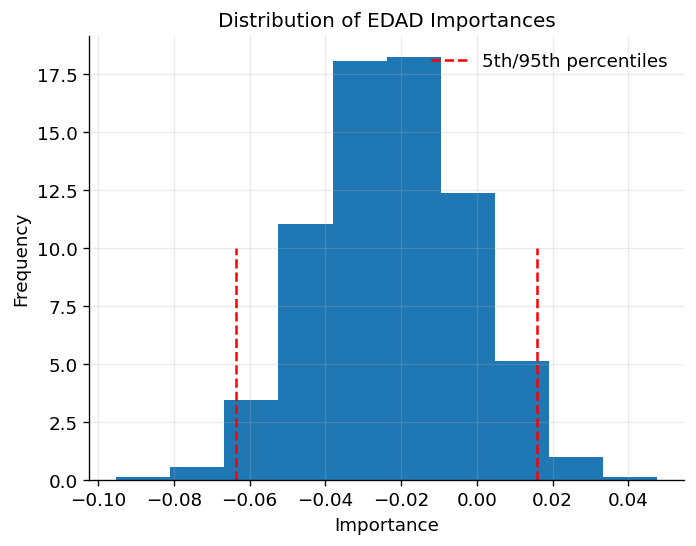

In [28]:
def boot_quantile(x, q, n_boot=1000):
    """Bootstrap quantiles."""
    boot_q = []
    for _ in range(n_boot):
        sample = np.random.choice(x, size=len(x), replace=True)
        boot_q.append(np.quantile(sample, q))
        
    #
    # np.mean(boot_q,axis= 1)
    boot_q = np.array(boot_q)
    print(boot_q.shape)
    print(np.mean(boot_q,axis=0))
    return np.percentile(boot_q, [2.5, 97.5])

feat_idx = {f: i for i, f in enumerate(FEATURES_ALL)}

for f in imp_df.feature:
    #q = np.quantile(pi["importances"][feat_idx[f], :], [0.05, 0.95])
    q = boot_quantile(pi["importances"][feat_idx[f], :], [0.05, 0.95])
    print(f"{f}: {q}")
    plt.figure()
    plt.hist(pi["importances"][feat_idx[f], :],density = True)
    plt.xlabel("Importance")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {f} Importances")
    plt.vlines(q, 0, 10, color="red", linestyle="--", label="5th/95th percentiles")
    plt.legend()
    plt.show()

(1000, 2)
[0.06185556 0.20022302]


(1000, 2)
[-0.00025873  0.03174603]
(1000, 2)
[-0.01587302  0.03174603]
(1000, 2)
[-0.01587302  0.01587302]
(1000, 2)
[-0.07275476  0.04761905]
(1000, 2)
[-0.04504603  0.00746429]
(1000, 2)
[-0.06261508  0.01587302]
Percentiles empíricos de la importancia de permutación (n_repeats=2000):
                 pretty  imp_mean     q05    q95  q_incluye_0
                   Expl    0.1299  0.0476 0.2063        False
                 Calcio    0.0149  0.0000 0.0317        False
     Anaplasma spp. (+)    0.0070 -0.0159 0.0317         True
             Vitamina D   -0.0003 -0.0159 0.0159         True
log(1+Carga piroplasma)   -0.0130 -0.0794 0.0476         True
                   Raza   -0.0162 -0.0476 0.0159         True
            Edad (años)   -0.0221 -0.0635 0.0159         True


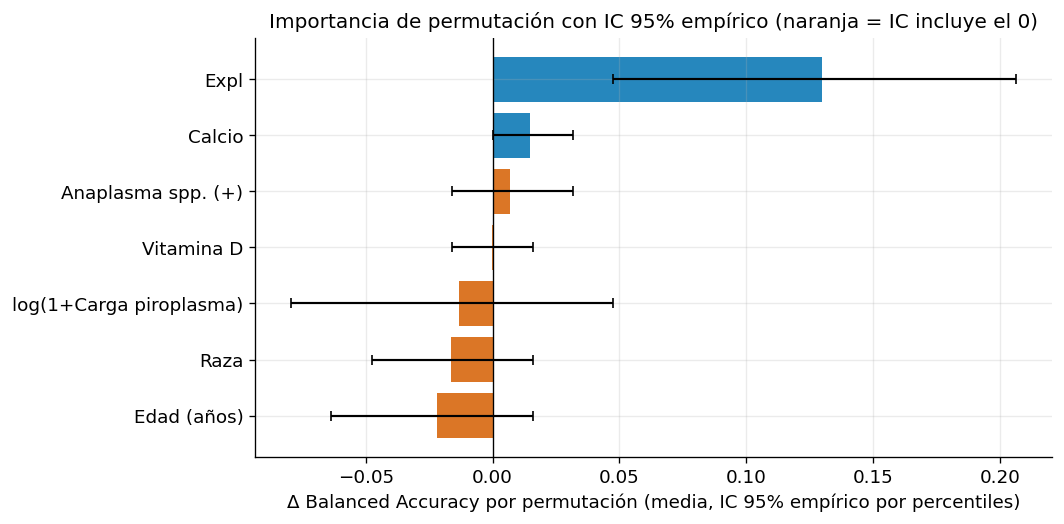

In [29]:
# IC 95% empírico de la importancia de permutación (percentiles de las repeticiones, np.quantile)
# A diferencia del IC95 anterior (aproximación normal media ± 1.96·SE), aquí se toman
# directamente los percentiles 2.5/50/97.5 de las n_repeats importancias por permutación
# de cada feature. No asume normalidad; útil si la distribución entre repeticiones es asimétrica.
feat_idx = {f: i for i, f in enumerate(FEATURES_ALL)}
Q_PROBS = [0.05, 0.95]
Q_COLS  = ["q05", "q95"]

quant_vals = np.array([
    #np.quantile(pi.importances[feat_idx[f], :], Q_PROBS)
    boot_quantile(pi.importances[feat_idx[f], :], Q_PROBS)
    for f in imp_df["feature"]
])
for col, vals in zip(Q_COLS, quant_vals.T):
    imp_df[col] = vals
imp_df["q_incluye_0"] = (imp_df["q05"] < 0) & (imp_df["q95"] >= 0)

print(f"Percentiles empíricos de la importancia de permutación (n_repeats={pi.importances.shape[1]}):")
print(imp_df[["pretty", "imp_mean", "q05", "q95", "q_incluye_0"]]
      .round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
order = imp_df.sort_values("imp_mean")
err = np.vstack([order.imp_mean - order.q05, order.q95  - order.imp_mean])
colors_q = [PALETTE[1] if inc else PALETTE[0] for inc in order.q_incluye_0]
ax.barh(order.pretty, order.imp_mean, xerr=err, color=colors_q, capsize=3, alpha=0.85,
        error_kw=dict(lw=1.3))
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ Balanced Accuracy por permutación (media, IC 95% empírico por percentiles)")
ax.set_title("Importancia de permutación con IC 95% empírico (naranja = IC incluye el 0)")
plt.tight_layout(); plt.savefig("figures/fig_03d2bal_perm_importance_ci95_quantile.png"); plt.show()

In [30]:
CV_SEL = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=tb.SEED)

bio_imp = imp_df[imp_df.feature != EXPL_COL].sort_values("imp_mean", ascending=True)
elim_order = bio_imp["feature"].tolist()
print(f"Orden de eliminación de biomarcadores: {elim_order}")
print(f"Covariable fija: {EXPL_COL}\n")
print("Paso 2: Eliminación hacia atrás de biomarcadores (Expl siempre presente)...\n")

current_bio = [f for f in FEATURES_ALL if f != EXPL_COL]  # solo biomarcadores; Expl se añade aparte
history = []

m0, s0 = cv_metrics_3d(current_bio, X_all, y, cv=CV_SEL)
history.append({"n": len(current_bio), "bio_features": current_bio.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_bio):2d} bio + Expl [baseline] BAL_ACC={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_bio or len(current_bio) <= 1: break
    test_bio = [f for f in current_bio if f != feat]
    m, s = cv_metrics_3d(test_bio, X_all, y, cv=CV_SEL)
    history.append({"n": len(test_bio), "bio_features": test_bio.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_bio):2d} bio + Expl [-{feat:20s}] BAL_ACC={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_bio = test_bio

hist_df = pd.DataFrame(history)

Orden de eliminación de biomarcadores: ['EDAD', 'RAZA2', 'PIROPLASMA_Q_log', 'VITAMINA_D', 'ANAPLASMA', 'CALCIO']
Covariable fija: Expl

Paso 2: Eliminación hacia atrás de biomarcadores (Expl siempre presente)...

   6 bio + Expl [baseline] BAL_ACC=0.714±0.090
   5 bio + Expl [-EDAD                ] BAL_ACC=0.684±0.071  Δ=-0.030
   4 bio + Expl [-RAZA2               ] BAL_ACC=0.698±0.095  Δ=-0.016
   3 bio + Expl [-PIROPLASMA_Q_log    ] BAL_ACC=0.679±0.131  Δ=-0.035
   2 bio + Expl [-VITAMINA_D          ] BAL_ACC=0.730±0.072  Δ=+0.016
   1 bio + Expl [-ANAPLASMA           ] BAL_ACC=0.738±0.061  Δ=+0.023


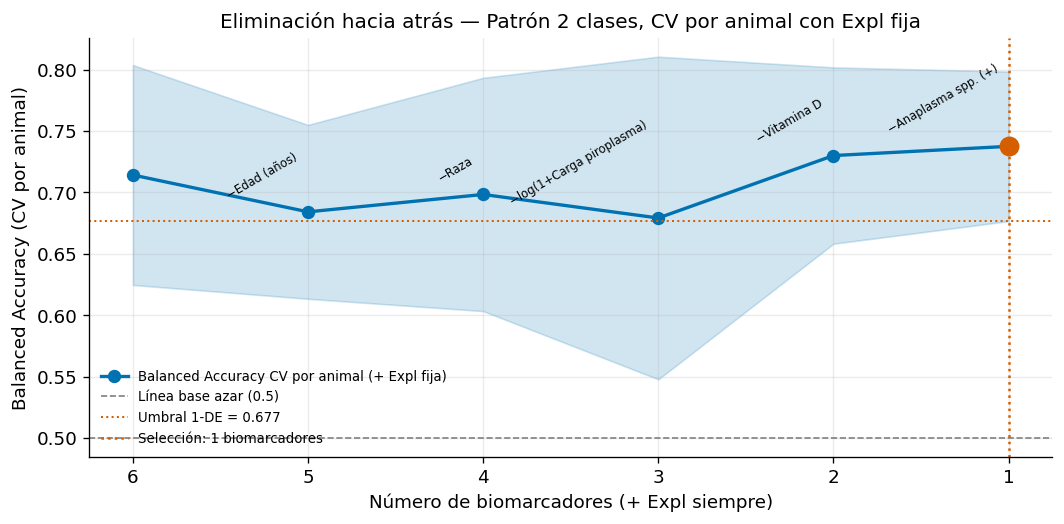


Biomarcadores SELECCIONADOS (1): ['CALCIO']


In [31]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7,
        label="Balanced Accuracy CV por animal (+ Expl fija)")
ax.fill_between(hist_df.n, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"],
                alpha=0.18, color=PALETTE[0])
ax.axhline(0.5, ls="--", color="grey", lw=1, label="Línea base azar (0.5)")

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
best_sd      = hist_df.loc[best_idx, "std"]
threshold    = best_mu - best_sd
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]

ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5,
           label=f"Selección: {int(parsimonious.n)} biomarcadores")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)

for _, row in hist_df.iterrows():
    label = tb.PRETTY.get(row.removed, row.removed) if row.removed != "—(baseline)" else ""
    if label:
        ax.annotate(f"−{label}", (row.n, row["mean"]),
                    textcoords="offset points", xytext=(-5, 8), fontsize=7, ha="right", rotation=30)

ax.set_xlabel("Número de biomarcadores (+ Expl siempre)")
ax.set_ylabel("Balanced Accuracy (CV por animal)")
ax.set_title("Eliminación hacia atrás — Patrón 2 clases, CV por animal con Expl fija")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_03d2bal_feature_selection_curve.png"); plt.show()

SELECTED_BIO_3D = list(parsimonious.bio_features)
print(f"\nBiomarcadores SELECCIONADOS ({len(SELECTED_BIO_3D)}): {SELECTED_BIO_3D}")

Calculando ROC-AUC para cada subconjunto (≈1 min)...
   6 bio [-—(baseline)         ] ROC=0.731±0.115
   5 bio [-EDAD                ] ROC=0.732±0.125
   4 bio [-RAZA2               ] ROC=0.729±0.128
   3 bio [-PIROPLASMA_Q_log    ] ROC=0.719±0.130
   2 bio [-VITAMINA_D          ] ROC=0.738±0.100
   1 bio [-ANAPLASMA           ] ROC=0.714±0.112


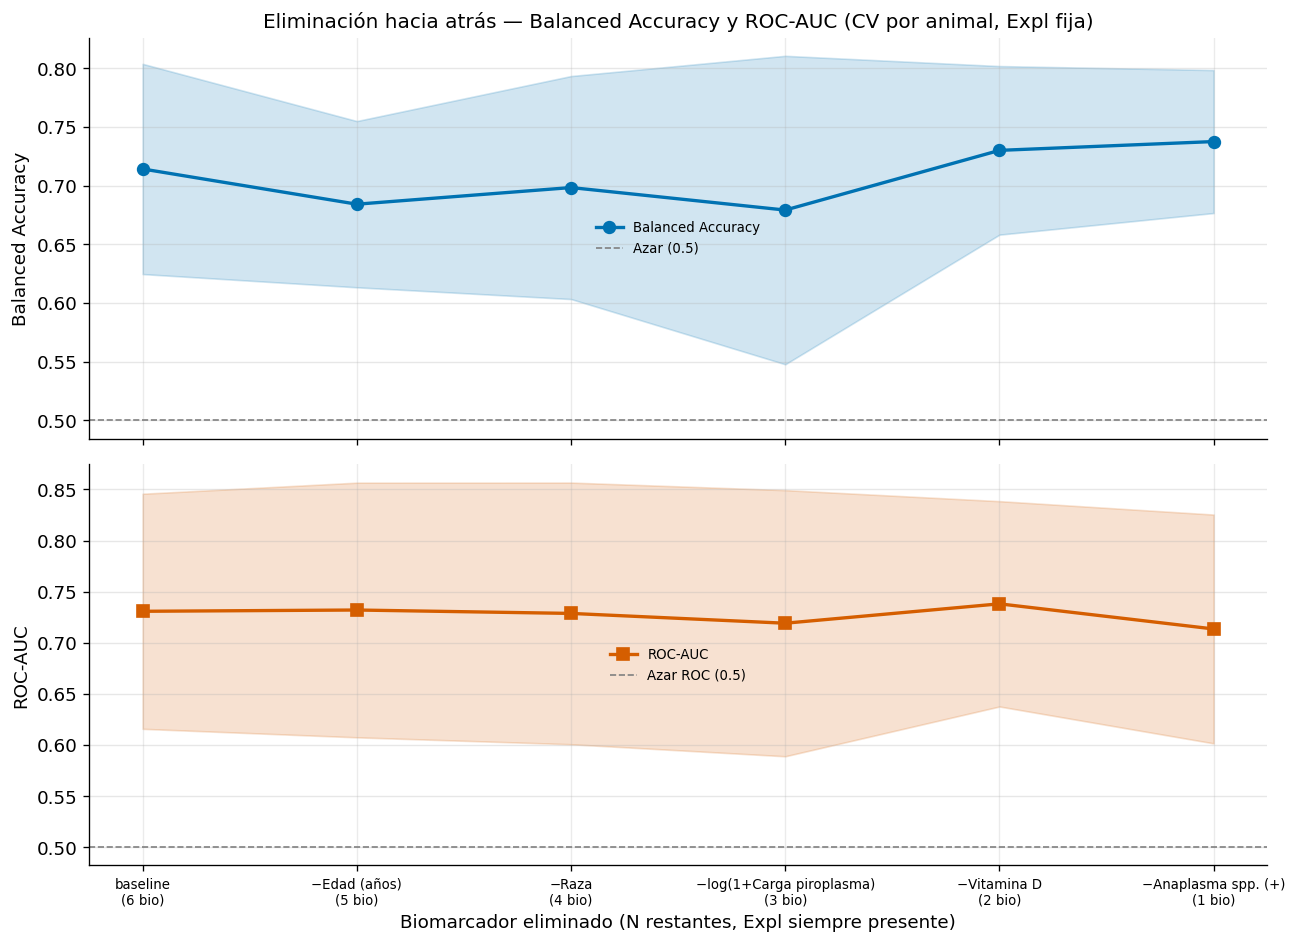

In [32]:
print("Calculando ROC-AUC para cada subconjunto (≈1 min)...")
roc_means, roc_stds = [], []
for _, row in hist_df.iterrows():
    feats_tmp = list(row["bio_features"]) + [EXPL_COL]
    Xs_tmp = X_all[feats_tmp]
    pipe_tmpl = make_pipe_3d(feats_tmp)
    rocs = []
    for tr, te in CV_SEL.split(Xs_tmp, y):
        if len(np.unique(y[te])) < 2: continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs_tmp.iloc[tr], y[tr])
        p = pf.predict_proba(Xs_tmp.iloc[te])
        try:
            rocs.append(roc_auc_score(y[te], p[:, 1]))
        except Exception:
            rocs.append(np.nan)
    roc_means.append(np.nanmean(rocs))
    roc_stds.append(np.nanstd(rocs))
    print(f"  {int(row.n):2d} bio [-{row['removed']:20s}] ROC={roc_means[-1]:.3f}±{roc_stds[-1]:.3f}")

hist_df = hist_df.assign(roc_mean=roc_means, roc_std=roc_stds)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
x = np.arange(len(hist_df))
labels = []
for _, row in hist_df.iterrows():
    if row["removed"] == "—(baseline)":
        lbl = f"baseline\n({int(row.n)} bio)"
    else:
        lbl = f"−{tb.PRETTY.get(row['removed'], row['removed'])}\n({int(row.n)} bio)"
    labels.append(lbl)

ax1 = axes[0]
ax1.plot(x, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="Balanced Accuracy")
ax1.fill_between(x, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"], alpha=0.18, color=PALETTE[0])
ax1.axhline(0.5, ls="--", color="grey", lw=1, label="Azar (0.5)")
ax1.set_ylabel("Balanced Accuracy"); ax1.legend(fontsize=8); ax1.grid(axis="y", alpha=0.3)
ax1.set_title("Eliminación hacia atrás — Balanced Accuracy y ROC-AUC (CV por animal, Expl fija)")

ax2 = axes[1]
ax2.plot(x, hist_df["roc_mean"], "s-", color=PALETTE[1], lw=2, ms=7, label="ROC-AUC")
ax2.fill_between(x, hist_df["roc_mean"]-hist_df["roc_std"], hist_df["roc_mean"]+hist_df["roc_std"], alpha=0.18, color=PALETTE[1])
ax2.axhline(0.5, ls="--", color="grey", lw=1, label="Azar ROC (0.5)")
ax2.set_ylabel("ROC-AUC"); ax2.legend(fontsize=8); ax2.grid(axis="y", alpha=0.3)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8, ha="center")
ax2.set_xlabel("Biomarcador eliminado (N restantes, Expl siempre presente)")
plt.tight_layout()
plt.savefig("figures/fig_03d2bal_feature_selection_metrics.png", bbox_inches="tight")
plt.show()

### 3.4 PIMP — significancia de la importancia (Altmann et al.)

Método **PIMP** (*Permutation IMPortance*, Altmann et al. 2010): a diferencia de la
importancia de permutación del paso 1 (que permuta cada **feature**), aquí se permuta la
**variable respuesta** `y`, preservando la estructura de correlación entre features. Esto
genera, para cada biomarcador, una distribución nula de la importancia Gini (impureza,
`feature_importances_` del RF) bajo H0 (no hay relación feature–respuesta).

Algoritmo:
1. Entrenar el RF con `X`, `y` originales → importancia Gini observada `GI_b,i` de cada feature `i`.
2. Repetir `n` veces: permutar `y` → `y*`, reentrenar el RF con `(X, y*)`, guardar la Gini `GI_H0,ij`.
3. Para cada feature, estimar la ECDF de `{GI_H0,i1, …, GI_H0,in}` y calcular
   `p-valor_i = P(GI_H0,i ≥ GI_b,i)` (proporción de importancias nulas que igualan o superan la observada).
4. `p-valor < α` ⇒ evidencia de que la feature está asociada a la respuesta.

Las columnas one-hot de una misma feature categórica (`Expl_*`) se suman para obtener la
importancia Gini de la feature original.

In [33]:
"""N_PERM_PIMP = 1000  # permutaciones de y (Altmann et al. sugieren cientos-miles; ~1-2 min con este n)

def gini_importance_by_feature(pipe, feature_list):
    # Suma la importancia Gini de las columnas one-hot de cada feature original.
    prep = pipe.named_steps["prep"]
    clf  = pipe.named_steps["clf"]
    names_out = prep.get_feature_names_out()
    raw_imp = clf.feature_importances_
    return {
        feat: raw_imp[[i for i, n in enumerate(names_out)
                       if n == feat or n.startswith(feat + "_")]].sum()
        for feat in feature_list
    }

print("PIMP — Paso 1: importancia Gini observada (modelo base, y original)...")
baseline_pipe_pimp = make_pipe_3d(FEATURES_ALL).fit(X_all, y)
gi_baseline = gini_importance_by_feature(baseline_pipe_pimp, FEATURES_ALL)

rng_pimp = np.random.default_rng(tb.SEED)
gi_null = {f: np.empty(N_PERM_PIMP) for f in FEATURES_ALL}

print(f"PIMP — Paso 2: {N_PERM_PIMP} permutaciones de y + reentrenamiento del RF...")
for j in range(N_PERM_PIMP):
    y_perm = rng_pimp.permutation(y)
    pipe_j = clone(baseline_pipe_pimp).fit(X_all, y_perm)
    gi_j = gini_importance_by_feature(pipe_j, FEATURES_ALL)
    for f in FEATURES_ALL:
        gi_null[f][j] = gi_j[f]

print("PIMP — Paso 3: p-valores empíricos (proporción de importancias nulas ≥ observada)...")
pimp_df = pd.DataFrame([
    dict(feature=f, gi_obs=gi_baseline[f], gi_null_mean=gi_null[f].mean(),
         gi_null_std=gi_null[f].std(),
         p_value=float(np.mean(gi_null[f] >= gi_baseline[f])))
    for f in FEATURES_ALL
]).sort_values("p_value").reset_index(drop=True)
pimp_df["p_fdr"] = tb.fdr(pimp_df["p_value"].values)
pimp_df["pretty"] = pimp_df.feature.map(lambda f: tb.PRETTY.get(f, f))
pimp_df["significativo"] = pimp_df["p_value"] < 0.05

print("\nResultado PIMP (ordenado por p-valor, α=0.05):")
print(pimp_df[["pretty", "gi_obs", "gi_null_mean", "gi_null_std", "p_value", "p_fdr", "significativo"]]
      .round(4).to_string(index=False))
"""

'N_PERM_PIMP = 1000  # permutaciones de y (Altmann et al. sugieren cientos-miles; ~1-2 min con este n)\n\ndef gini_importance_by_feature(pipe, feature_list):\n    # Suma la importancia Gini de las columnas one-hot de cada feature original.\n    prep = pipe.named_steps["prep"]\n    clf  = pipe.named_steps["clf"]\n    names_out = prep.get_feature_names_out()\n    raw_imp = clf.feature_importances_\n    return {\n        feat: raw_imp[[i for i, n in enumerate(names_out)\n                       if n == feat or n.startswith(feat + "_")]].sum()\n        for feat in feature_list\n    }\n\nprint("PIMP — Paso 1: importancia Gini observada (modelo base, y original)...")\nbaseline_pipe_pimp = make_pipe_3d(FEATURES_ALL).fit(X_all, y)\ngi_baseline = gini_importance_by_feature(baseline_pipe_pimp, FEATURES_ALL)\n\nrng_pimp = np.random.default_rng(tb.SEED)\ngi_null = {f: np.empty(N_PERM_PIMP) for f in FEATURES_ALL}\n\nprint(f"PIMP — Paso 2: {N_PERM_PIMP} permutaciones de y + reentrenamiento del RF..."

In [34]:
"""order_feats = pimp_df.sort_values("gi_obs").feature.tolist()
n_f = len(order_feats)
fig, axes = plt.subplots(1, n_f, figsize=(3.0 * n_f, 3.2), sharey=False)
for ax, feat in zip(axes, order_feats):
    row = pimp_df.loc[pimp_df.feature == feat].iloc[0]
    ax.hist(gi_null[feat], bins=25, color=PALETTE[0], alpha=0.7)
    ax.axvline(row.gi_obs, color=PALETTE[1], lw=2)
    ax.set_title(f"{row.pretty}\np={row.p_value:.3f}", fontsize=8)
    ax.set_xlabel("GI nula", fontsize=7); ax.tick_params(labelsize=7)
plt.suptitle("PIMP — distribución nula de importancia Gini (permutando y) vs. valor observado (línea)", y=1.05)
plt.tight_layout(); plt.savefig("figures/fig_03d2bal_pimp_distributions.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * n_f)))
order = pimp_df.sort_values("gi_obs")
colors_bar = [PALETTE[1] if s else PALETTE[0] for s in order.significativo]
ax.barh(order.pretty, order.gi_obs, color=colors_bar, alpha=0.85)
for i, (_, row) in enumerate(order.iterrows()):
    ax.text(row.gi_obs, i, f"  p={row.p_value:.3f}", va="center", fontsize=8)
ax.set_xlabel("Importancia Gini observada")
ax.set_title("PIMP — importancia Gini y significancia (naranja = p<0.05)")
plt.tight_layout(); plt.savefig("figures/fig_03d2bal_pimp_importance.png", bbox_inches="tight"); plt.show()

print(f"Features significativas (PIMP, p<0.05): {pimp_df.loc[pimp_df.significativo, 'feature'].tolist()}")
"""

'order_feats = pimp_df.sort_values("gi_obs").feature.tolist()\nn_f = len(order_feats)\nfig, axes = plt.subplots(1, n_f, figsize=(3.0 * n_f, 3.2), sharey=False)\nfor ax, feat in zip(axes, order_feats):\n    row = pimp_df.loc[pimp_df.feature == feat].iloc[0]\n    ax.hist(gi_null[feat], bins=25, color=PALETTE[0], alpha=0.7)\n    ax.axvline(row.gi_obs, color=PALETTE[1], lw=2)\n    ax.set_title(f"{row.pretty}\np={row.p_value:.3f}", fontsize=8)\n    ax.set_xlabel("GI nula", fontsize=7); ax.tick_params(labelsize=7)\nplt.suptitle("PIMP — distribución nula de importancia Gini (permutando y) vs. valor observado (línea)", y=1.05)\nplt.tight_layout(); plt.savefig("figures/fig_03d2bal_pimp_distributions.png", bbox_inches="tight"); plt.show()\n\nfig, ax = plt.subplots(figsize=(8, max(3, 0.45 * n_f)))\norder = pimp_df.sort_values("gi_obs")\ncolors_bar = [PALETTE[1] if s else PALETTE[0] for s in order.significativo]\nax.barh(order.pretty, order.gi_obs, color=colors_bar, alpha=0.85)\nfor i, (_, row) in

## 4. Evaluación del modelo final (CV por animal, 5×10)

Modelo final — features (3): ['VITAMINA_D', 'ANAPLASMA', 'Expl']

Métricas CV por animal (5×10, con Expl):
  BAL_ACC       = 0.723 ± 0.070   (azar = 0.5)
  ROC           = 0.763 ± 0.128   (azar = 0.5)
  Sensibilidad  = 0.572 ± 0.191   (recall clase 1 = generalizado)
  Especificidad = 0.875 ± 0.124   (recall clase 0 = localizado)


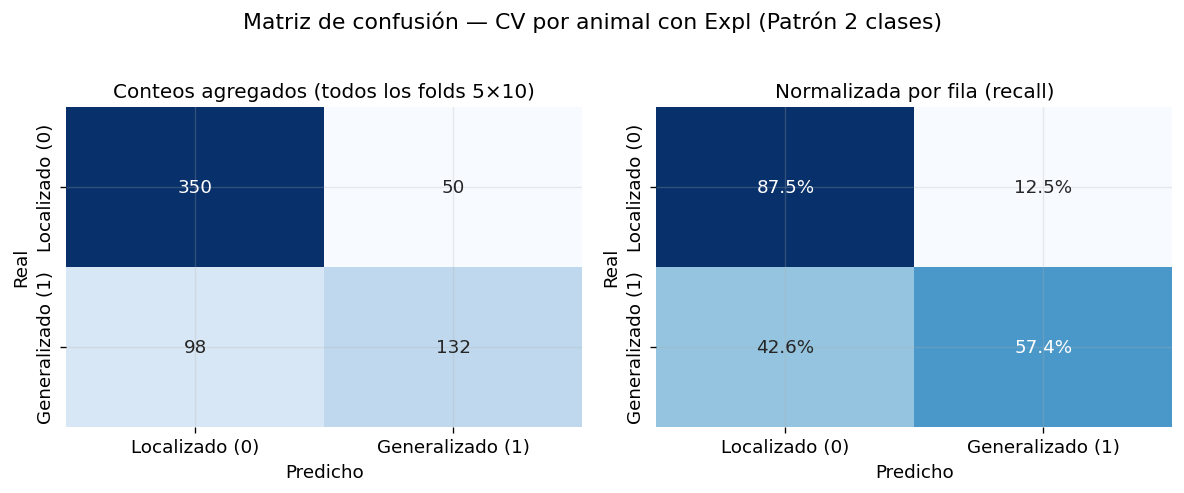

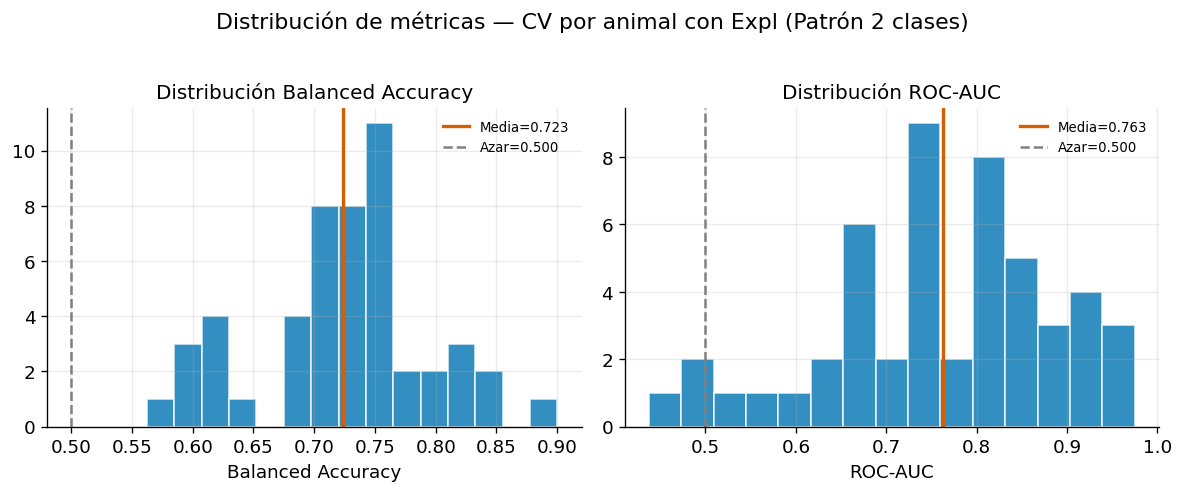

In [35]:
SELECTED_BIO_3D = ['VITAMINA_D', "ANAPLASMA"]  # ajustar tras revisar backward elim (2 clases)
FEATS_FINAL_3D = SELECTED_BIO_3D + [EXPL_COL]
Xs = X_all[FEATS_FINAL_3D].copy()
print(f"Modelo final — features ({len(FEATS_FINAL_3D)}): {FEATS_FINAL_3D}\n")

detailed_df = cv_metrics_3d(SELECTED_BIO_3D, X_all, y, cv=CV_OUTER, detailed=True, n_estimators=700)
m = detailed_df.mean(); s = detailed_df.std()

print("Métricas CV por animal (5×10, con Expl):")
print(f"  BAL_ACC       = {m.bal_acc:.3f} ± {s.bal_acc:.3f}   (azar = 0.5)")
print(f"  ROC           = {m.roc_mac:.3f} ± {s.roc_mac:.3f}   (azar = 0.5)")
print(f"  Sensibilidad  = {m.sens:.3f} ± {s.sens:.3f}   (recall clase 1 = generalizado)")
print(f"  Especificidad = {m.spec:.3f} ± {s.spec:.3f}   (recall clase 0 = localizado)")

# Matriz de confusión agregada: suma de conteos (tn, fp, fn, tp) de todos los folds del CV repetido (5×10)
cm_agg = np.array([[detailed_df.tn.sum(), detailed_df.fp.sum()],
                    [detailed_df.fn.sum(), detailed_df.tp.sum()]])
cm_pct = cm_agg / cm_agg.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, fmt, title in zip(axes, [cm_agg, cm_pct], ["d", ".1%"],
                               ["Conteos agregados (todos los folds 5×10)", "Normalizada por fila (recall)"]):
    sns.heatmap(mat, annot=True, fmt=fmt, cmap="Blues", cbar=False,
                xticklabels=["Localizado (0)", "Generalizado (1)"],
                yticklabels=["Localizado (0)", "Generalizado (1)"], ax=ax)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real"); ax.set_title(title)
plt.suptitle("Matriz de confusión — CV por animal con Expl (Patrón 2 clases)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_03d2bal_confusion_matrix.png", bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title, chance in zip(axes,
                                   ["bal_acc", "roc_mac"],
                                   ["Balanced Accuracy", "ROC-AUC"],
                                   [0.5, 0.5]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    ax.axvline(chance, color="grey", ls="--", lw=1.5, label=f"Azar={chance:.3f}")
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle("Distribución de métricas — CV por animal con Expl (Patrón 2 clases)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_03d2bal_metrics_dist.png", bbox_inches="tight"); plt.show()

## 5. Interpretabilidad global — SHAP

SHAP para la clase **generalizado** (clase 1) frente a localizado (clase 0).
Las columnas `Expl_*` muestran el efecto granja residual en el modelo.

In [36]:
FINAL_3D = make_pipe_3d(FEATS_FINAL_3D, n_estimators=500).fit(Xs, y)
print(f"OOB Score (en muestra): {FINAL_3D.named_steps['clf'].oob_score_:.3f}")

prep_3d  = FINAL_3D.named_steps["prep"]
clf_3d   = FINAL_3D.named_steps["clf"]
Xt_3d    = prep_3d.transform(Xs)
names_3d = list(prep_3d.get_feature_names_out())

explainer_3d = shap.TreeExplainer(clf_3d)
shap_vals_3d = explainer_3d.shap_values(Xt_3d)

if isinstance(shap_vals_3d, list):
    sv_d_list = shap_vals_3d
    sv_d_mean = np.mean([np.abs(s) for s in sv_d_list], axis=0)
else:
    arr = np.asarray(shap_vals_3d)
    if arr.ndim == 3:
        sv_d_list = [arr[:, :, i] for i in range(arr.shape[2])]
        sv_d_mean = np.abs(arr).mean(axis=2)
    else:
        sv_d_list = [arr]; sv_d_mean = np.abs(arr)

classes_sorted = np.sort(np.unique(y))
idx_gen = np.where(classes_sorted == 1)[0][0]
sv_d_gen = sv_d_list[idx_gen]

exp_val_3d = (float(explainer_3d.expected_value[idx_gen])
              if isinstance(explainer_3d.expected_value, (list, np.ndarray))
              else float(explainer_3d.expected_value))

print(f"Features tras preprocesamiento : {names_3d}")
print(f"Clases ordenadas               : {classes_sorted}")
print(f"Índice clase generalizado      : {idx_gen}")
print(f"SHAP values generalizado shape : {sv_d_gen.shape}")
print(f"Expected value (clase generalizado): {exp_val_3d:.4f}")

OOB Score (en muestra): 0.778
Features tras preprocesamiento : ['VITAMINA_D', 'ANAPLASMA', 'Expl_VA32D', 'Expl_VC30D', 'Expl_VC94C', 'Expl_WZ72B']
Clases ordenadas               : [0 1]
Índice clase generalizado      : 1
SHAP values generalizado shape : (63, 6)
Expected value (clase generalizado): 0.5001


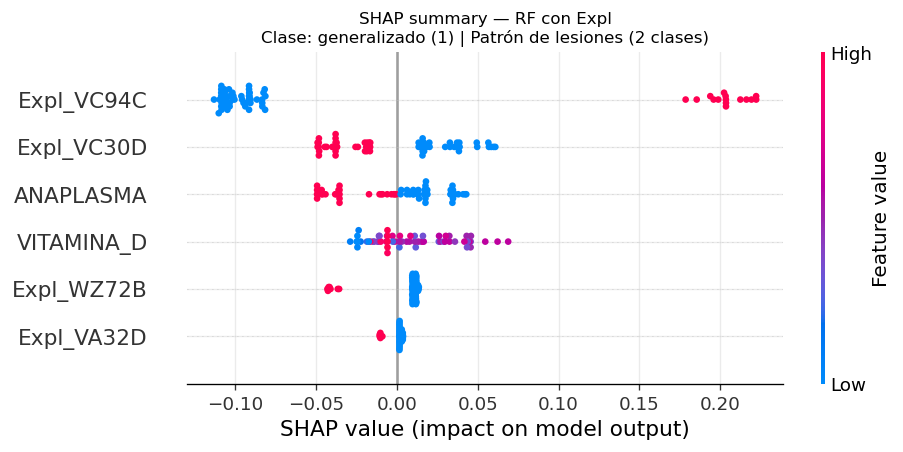

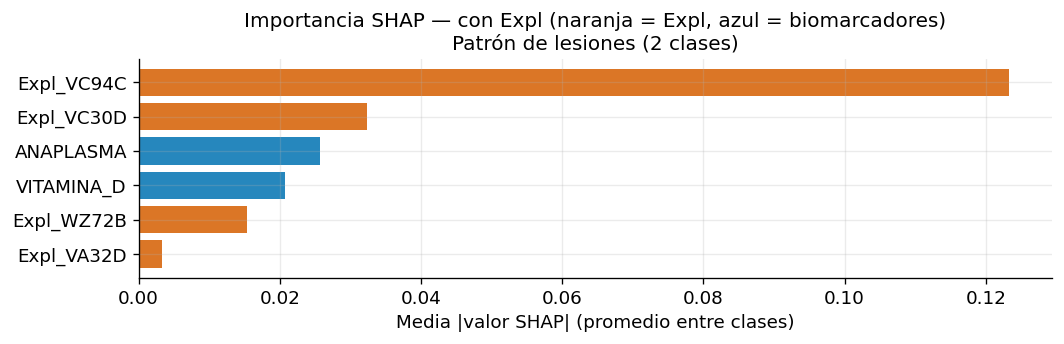

In [37]:
plt.figure(figsize=(9, max(4, 0.5 * len(names_3d))))
shap.summary_plot(sv_d_gen, Xt_3d, feature_names=names_3d, show=False, max_display=len(names_3d))
plt.title("SHAP summary — RF con Expl\nClase: generalizado (1) | Patrón de lesiones (2 clases)", fontsize=10)
plt.tight_layout(); plt.savefig("figures/fig_03d2bal_shap_summary.png", bbox_inches="tight"); plt.show()

mean_abs_3d = sv_d_mean.mean(0)
si_3d = pd.DataFrame({"feature": names_3d, "mean_abs": mean_abs_3d}).sort_values("mean_abs")
colors_shap = [PALETTE[1] if "Expl" in f else PALETTE[0] for f in si_3d.feature]
fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(names_3d))))
ax.barh(si_3d.feature, si_3d.mean_abs, color=colors_shap, alpha=0.85)
ax.set_xlabel("Media |valor SHAP| (promedio entre clases)")
ax.set_title("Importancia SHAP — con Expl (naranja = Expl, azul = biomarcadores)\nPatrón de lesiones (2 clases)")
plt.tight_layout(); plt.savefig("figures/fig_03d2bal_shap_importance.png"); plt.show()

In [38]:
shap.initjs()
order = np.argsort(FINAL_3D.predict_proba(Xs)[:, idx_gen])
fp = shap.force_plot(exp_val_3d, sv_d_gen[order], Xt_3d[order], feature_names=names_3d)
shap.save_html("figures/fig_03d2bal_shap_force_plot_global.html", fp)
display(fp)

In [ ]:
from scipy.stats import spearmanr
imp_runs_3d = []
cv_stab = StratifiedKFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs, y):
    if len(np.unique(y[te])) < 2: continue
    pf = clone(make_pipe_3d(FEATS_FINAL_3D)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="balanced_accuracy", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_3d.append(pd.Series(pi_f.importances_mean, index=FEATS_FINAL_3D))

imp_mat_3d = pd.concat(imp_runs_3d, axis=1)
imp_ord_3d = imp_mat_3d.mean(axis=1).sort_values().index
R = imp_mat_3d.fillna(0)
cors = [spearmanr(R.iloc[:,i], R.iloc[:,j]).correlation
        for i in range(R.shape[1]) for j in range(i+1, R.shape[1])]

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(FEATS_FINAL_3D))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_3d],
        imp_mat_3d.mean(axis=1)[imp_ord_3d],
        xerr=imp_mat_3d.std(axis=1)[imp_ord_3d],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ Balanced Accuracy por permutación (CV 5-fold, media ± SD)")
ax.set_title("Importancia por permutación — CV por animal con Expl (Patrón 2 clases)")
plt.tight_layout(); plt.savefig("figures/fig_03d2bal_perm_importance_cv.png"); plt.show()
print(f"Estabilidad Spearman entre folds: {np.nanmean(cors):.3f}")

## 6. Partial Dependence Plots + ICE

In [ ]:
CONT_3D = [f for f in FEATS_FINAL_3D if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_3D:
    CONT_3D = [f for f in FEATS_FINAL_3D if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_3D}")
if CONT_3D:
    n_c = len(CONT_3D)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_3D, Xs, CONT_3D,grid_resolution=500, kind="average",
        target=1, ax=axes, line_kw={"color": PALETTE[0], "lw": 2})
    for ax, f in zip(axes, CONT_3D):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("PDP — RF con Expl (P(generalizado), marginalizado sobre Expl)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03d2bal_pdp.png", bbox_inches="tight"); plt.show()

    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_3D, Xs, CONT_3D,grid_resolution=500, kind="both",
        target=1, ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True)
    for ax, f in zip(axes, CONT_3D):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("ICE + PDP — RF con Expl (P(generalizado))", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03d2bal_ice.png", bbox_inches="tight"); plt.show()

### 6.1 PDP para variables categóricas

`FEATS_FINAL_3D` incluye variables categóricas o de baja cardinalidad (p. ej. `Expl`, y biomarcadores serológicos binarios) que quedan fuera de `CONT_3D`. Para estas se calcula un PDP categórico: se sustituye el valor de la variable por cada uno de sus niveles en **todas** las filas y se promedia `predict_proba` (clase generalizado), igual que el PDP continuo pero representado como barras en vez de curva.


In [ ]:
CAT_3D_PLOT = [f for f in FEATS_FINAL_3D if f not in CONT_3D]
print(f"Features categóricas/discretas para PDP: {CAT_3D_PLOT}")

if CAT_3D_PLOT:
    n_cat = len(CAT_3D_PLOT)
    fig, axes = plt.subplots(1, n_cat, figsize=(5 * n_cat, 4.5))
    if n_cat == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(
        FINAL_3D, Xs, CAT_3D_PLOT, grid_resolution=500, kind="average", target=1,
        categorical_features=CAT_3D_PLOT, ax=axes)
    for ax, f in zip(axes, CAT_3D_PLOT):
        for bar in ax.patches:
            bar.set_color(PALETTE[0]); bar.set_alpha(0.85)
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
        ax.set_ylabel("P(generalizado)")
    plt.suptitle("PDP variables categóricas — RF con Expl (P(generalizado), sustitución global)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03d2bal_pdp_cat.png", bbox_inches="tight"); plt.show()
else:
    print("No hay variables categóricas adicionales fuera de CONT_3D.")


## 7. Accumulated Local Effects (ALE)

In [ ]:
def ale_1d(model, X, feat, bins=100):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict_proba(hi)[:, idx_gen] - model.predict_proba(lo)[:, idx_gen]).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_3D:
    n_c = len(CONT_3D)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_3D):
        cx, ale = ale_1d(FINAL_3D, Xs, feat)
        if len(cx) == 0: ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0], label="↑ riesgo generalizado")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1], label="↓ riesgo generalizado")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.legend(fontsize=8)
    plt.suptitle("ALE — RF con Expl (clase generalizado)\nPatrón de lesiones (2 clases)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03d2bal_ale.png", bbox_inches="tight"); plt.show()

### 7.1 ALE para variables categóricas

El ALE 1D estándar requiere un orden natural en los valores del predictor (usa cuantiles). Para variables categóricas nominales no hay un orden natural, así que se ordenan los niveles por su media local de predicción (proxy de similitud cuando no existe otro criterio) y se acumulan las diferencias locales entre niveles consecutivos usando **solo** las filas que realmente tienen uno u otro nivel — a diferencia del PDP, no se sustituye el nivel en toda la muestra, lo que evita extrapolar a combinaciones granja/biomarcador que no existen en los datos.


In [ ]:
def ale_categorical(model, X, feat, idx_class):
    """ALE para variable categórica: ordena los niveles por su media local de predicción y
    acumula diferencias locales entre niveles consecutivos (solo con filas observadas de
    cada nivel), evitando la sustitución global del PDP."""
    levels = X[feat].dropna().unique().tolist()
    if len(levels) < 2:
        return [], np.array([])
    levels = sorted(levels, key=lambda lv: model.predict_proba(X.loc[X[feat] == lv])[:, idx_class].mean())
    effects = [0.0]
    for i in range(1, len(levels)):
        l0, l1 = levels[i - 1], levels[i]
        sub = X.loc[X[feat].isin([l0, l1])]
        lo = sub.copy(); lo[feat] = l0
        hi = sub.copy(); hi[feat] = l1
        diff = (model.predict_proba(hi)[:, idx_class] - model.predict_proba(lo)[:, idx_class]).mean()
        effects.append(effects[-1] + diff)
    effects = np.array(effects)
    effects -= effects.mean()
    return levels, effects

if CAT_3D_PLOT:
    n_cat = len(CAT_3D_PLOT)
    fig, axes = plt.subplots(1, n_cat, figsize=(5 * n_cat, 4))
    if n_cat == 1: axes = [axes]
    for ax, feat in zip(axes, CAT_3D_PLOT):
        levels, ale_c = ale_categorical(FINAL_3D, Xs, feat, idx_gen)
        if len(levels) == 0:
            ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        colors_c = [PALETTE[0] if v >= 0 else PALETTE[1] for v in ale_c]
        ax.bar([str(l) for l in levels], ale_c, color=colors_c, alpha=0.85)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.set_ylabel("Efecto local acumulado")
    plt.suptitle("ALE variables categóricas — RF con Expl (clase generalizado, orden por media local)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03d2bal_ale_cat.png", bbox_inches="tight"); plt.show()


## 8. SHAP waterfall — interpretabilidad local

In [ ]:
p_gen = FINAL_3D.predict_proba(Xs)[:, idx_gen]
idx_pos = int(np.argmax(p_gen))
idx_neg = int(np.argmin(p_gen))

shap_exp_3d = shap.Explanation(values=sv_d_gen, base_values=exp_val_3d,
                                data=Xt_3d, feature_names=names_3d)

for tag, idx in [("alto_riesgo_gen", idx_pos), ("bajo_riesgo_gen", idx_neg)]:
    fig, _ = plt.subplots(figsize=(10, 4))
    shap.plots.waterfall(shap_exp_3d[idx], max_display=len(names_3d), show=False)
    plt.title(f"SHAP local — animal {tag.replace('_',' ')} (p_gen={p_gen[idx]:.3f})")
    plt.tight_layout()
    plt.savefig(f"figures/fig_03d2bal_waterfall_{tag}.png", bbox_inches="tight"); plt.show()
    print(f"Animal {idx}: p_gen={p_gen[idx]:.3f}, clase real={y[idx]}, pred={FINAL_3D.predict(Xs)[idx]}")

## 9. Contrafactuales (sobre biomarcadores, granja fija)

In [ ]:
def find_cf(model, row_dict, feat, lo, hi, target_cls, n=500):
    for v in np.linspace(lo, hi, n):
        r = dict(row_dict); r[feat] = v
        if int(model.predict(pd.DataFrame([r]))[0]) == target_cls:
            return v
    return None

high_row = Xs.iloc[idx_pos].copy()
low_row  = Xs.iloc[idx_neg].copy()
target_cls = 1

print("=" * 60)
print("CONTRAFACTUALES — biomarcadores (granja fija, clase generalizado)")
print("=" * 60)
for tag, row, tgt in [("ALTO riesgo gen.", high_row, 0), ("BAJO riesgo gen.", low_row, target_cls)]:
    pred = int(FINAL_3D.predict(pd.DataFrame([row]))[0])
    p    = FINAL_3D.predict_proba(pd.DataFrame([row]))[0, idx_gen]
    print(f"\nAnimal {tag} (predicha={pred}, p_gen={p:.3f}, granja={row[EXPL_COL]}), objetivo → clase {tgt}")
    for feat in CONT_3D:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf = find_cf(FINAL_3D, row.to_dict(), feat, lo_v, hi_v, tgt)
        cur = row[feat]
        if cf is not None:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → cf={cf:.2f} (Δ={cf-cur:+.2f})")
        else:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → no alcanzable")

In [ ]:
if CONT_3D:
    n_c = len(CONT_3D)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_3D):
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        grid = np.linspace(lo_v, hi_v, 200)
        for tag, row, color in [("Alto riesgo gen.", high_row, PALETTE[1]),
                                 ("Bajo riesgo gen.", low_row, PALETTE[0])]:
            probs = [FINAL_3D.predict_proba(pd.DataFrame([{**row.to_dict(), feat: v}]))[0, idx_gen] for v in grid]
            ax.plot(grid, probs, color=color, lw=2, label=f"{tag} (granja={row[EXPL_COL]})")
            ax.axvline(row[feat], color=color, ls=":", lw=1.2, alpha=0.7)
        ax.axhline(0.5, color="grey", ls="--", lw=0.8, label="Azar (0.5)")
        ax.set_xlabel(tb.PRETTY.get(feat, feat))
        ax.set_ylabel("P(generalizado)")
        ax.set_title(f"Contrafactual: {tb.PRETTY.get(feat,feat)}"); ax.legend(fontsize=7)
    plt.suptitle("Sensibilidad contrafactual — RF con Expl (granja fija)\nPatrón de lesiones (2 clases)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03d2bal_cf_curves.png", bbox_inches="tight"); plt.show()

## 10. Síntesis y triangulación

### Tabla comparativa

| Métrica | Nb 3d — 3 clases (con -1) | **Nb 3d — 2 clases (localizado vs. generalizado)** |
|---|---|---|
| BAL_ACC | — | **—** |
| ROC-AUC | — | **—** |
| CV strategy | RepeatedSKFold + Expl feature | **RepeatedSKFold + Expl feature** |
| Expl como feature | Sí (OHE, siempre fija) | **Sí (OHE, siempre fija)** |

### Guía de interpretación

- **Si BAL_ACC(2 clases) >> BAL_ACC(3 clases):** separar localizado vs. generalizado es más
  fácil para el modelo que distinguir además a los animales sin lesión.

- **Si BAL_ACC(2 clases) ≈ BAL_ACC(3 clases):** la dificultad principal no está en discriminar
  sin lesión vs. lesionado, sino en el patrón lesional en sí.

- **SHAP de Expl_*:** si las columnas de granja tienen SHAP elevado para la clase
  generalizado, el patrón lesional está fuertemente determinado por la granja
  (diferencias en cepa, presión de infección o manejo).